# Part 1 — Word2Vec and t-SNE

**Purpose:** learn how corpus design changes word embeddings, inspect cosine similarity in the original vector space, and cautiously display selected vectors in two dimensions.

**Runtime:** about 25 minutes. **Objectives:** distinguish more rows from more varied contexts; train skip-gram Word2Vec; interpret cosine similarity; identify t-SNE limits.

**Safety and scope:** all sentences are fictional. These small synthetic corpora demonstrate a mechanism; they do not represent patients, clinical language, or validated meaning. Run cells from top to bottom.

## 0. Setup

This cell imports the documented libraries and fixes random state. [`gensim.models.Word2Vec`](https://radimrehurek.com/gensim/models/word2vec.html) learns vectors from local contexts. [`sklearn.manifold.TSNE`](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) later makes a 2-D display. `workers=1` reduces one source of training variation.

In [1]:
import re, random, sys
from collections import Counter
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec

RANDOM_STATE = 42
random.seed(RANDOM_STATE); np.random.seed(RANDOM_STATE)
print({'python': sys.version.split()[0], 'numpy': np.__version__, 'pandas': pd.__version__})

{'python': '3.13.5', 'numpy': '2.2.6', 'pandas': '2.2.3'}


## 1. Diagnose a deliberately repetitive baseline

A **token** is a text unit. A **context window** selects nearby tokens as training examples. The original fixture expands every subject × action × modifier combination. This is reproducible, but words occupying the same template slot receive almost identical evidence. Inspect examples, unique sentences, and vocabulary—not just row count.

In [2]:
CORPUS_BLOCKS = [
 {'subjects':['clinic','nurse','scheduler','portal','reception'],'actions':['books appointment','confirms visit','schedules followup','sends reminder'],'modifiers':['for patient','before monday','through portal','at clinic']},
 {'subjects':['laboratory','technician','nurse','clinic','portal'],'actions':['records result','reviews screening','sends result','requests referral'],'modifiers':['after screening','for review','through portal','to clinic']},
 {'subjects':['privacy','consent','auditor','record','access'],'actions':['protects record','requires consent','logs access','supports audit'],'modifiers':['for privacy','before release','in system','during audit']}]
baseline_raw = [f"{s} {a} {m}" for b in CORPUS_BLOCKS for s in b['subjects'] for a in b['actions'] for m in b['modifiers']]
baseline_sentences = [re.findall(r'[a-z]+', text.lower()) for text in baseline_raw]
baseline_vocabulary = sorted({token for row in baseline_sentences for token in row})
assert len(baseline_raw) == len(set(baseline_raw)) == 240 and len(baseline_vocabulary) == 44
print(*baseline_raw[:3], sep='\n')
print(f"\nrows = unique sentences = {len(baseline_raw):,}; vocabulary = {len(baseline_vocabulary)}")

clinic books appointment for patient
clinic books appointment before monday
clinic books appointment through portal

rows = unique sentences = 240; vocabulary = 44


### What do we see?

The baseline has 240 unique strings, but its Cartesian templates make many substitutions mechanically equivalent. Duplicating these rows would increase token counts without adding a new context. **More data helps only when it adds relevant variation.**

## 2. Build a more varied fictional corpus

Each domain now has five sentence families with role-specific slots. We sample deterministically, keep unique rendered sentences, then repeat them three times so this tiny model sees each example more than once. Repetition stabilizes training; the 364 unique sentences provide the new information. Articles are removed with a visible, simple preprocessing rule.

In [3]:
DOMAIN_FRAMES = {
'scheduling': [
 ('the {role} {action} the {visit} using the {channel}', {'role':['scheduler','reception','nurse'],'action':['books','confirms','reschedules'],'visit':['appointment','followup','visit'],'channel':['portal','telephone','calendar']}),
 ('the patient uses the {channel} to {action} a {visit}', {'channel':['portal','telephone'],'action':['book','confirm','change'],'visit':['appointment','followup','visit']}),
 ('the {channel} sends a {message} before the {visit}', {'channel':['portal','clinic','system'],'message':['reminder','confirmation','notice'],'visit':['appointment','followup','visit']}),
 ('the {role} checks the {detail} and updates the {channel}', {'role':['scheduler','reception','nurse'],'detail':['date','time','referral'],'channel':['calendar','portal','record']}),
 ('the clinic receives a {request} from the patient', {'request':['booking','cancellation','referral','question']})],
'results': [
 ('the {role} {action} the {test} result in the {location}', {'role':['technician','laboratory','nurse'],'action':['records','checks','releases'],'test':['screening','blood','imaging'],'location':['record','portal','system']}),
 ('the {role} reviews the {item} before {action}', {'role':['technician','nurse','clinician'],'item':['result','screening','report'],'action':['release','followup','referral']}),
 ('the laboratory sends the {item} to the {destination}', {'item':['result','report','screening'],'destination':['clinic','record','portal']}),
 ('the clinic requests {action} after the {item}', {'action':['review','followup','referral'],'item':['result','screening','report']}),
 ('the patient receives a {message} when the result is {state}', {'message':['notice','telephone call','portal message'],'state':['ready','reviewed','released']})],
'governance': [
 ('the {role} {action} {object} in the {location}', {'role':['auditor','privacy officer','administrator'],'action':['reviews','logs','checks'],'object':['access','consent','audit'],'location':['record','system','register']}),
 ('the {policy} policy {action} the patient {object}', {'policy':['privacy','consent','access'],'action':['protects','limits','documents'],'object':['record','choice','information']}),
 ('the system logs {object} for the {purpose}', {'object':['access','release','change'],'purpose':['audit','privacy','review']}),
 ('the {role} requires {item} before record {action}', {'role':['auditor','privacy officer','administrator'],'item':['consent','approval','verification'],'action':['access','release','change']}),
 ('the audit checks whether {item} follows the privacy policy', {'item':['access','consent','release','documentation']})]}

rng = random.Random(RANDOM_STATE)
sampled = []
for domain, frames in DOMAIN_FRAMES.items():
    for template, slots in frames:
        for _ in range(100):
            sampled.append((domain, template.format(**{key:rng.choice(values) for key,values in slots.items()})))
unique_examples = list(dict.fromkeys(sampled))
varied_examples = unique_examples * 3
STOPWORDS = {'a','an','the'}
tokenized_sentences = [[t for t in re.findall(r'[a-z]+', text.lower()) if t not in STOPWORDS] for _,text in varied_examples]
vocabulary = sorted({t for row in tokenized_sentences for t in row})
assert len(unique_examples) == 364 and len(varied_examples) == 1092 and len(vocabulary) == 83
print(f"unique sentences: {len(unique_examples):,}; training rows: {len(varied_examples):,}; vocabulary: {len(vocabulary)}")
print(*[f"{domain:10} | {text}" for domain,text in unique_examples[::130]], sep='\n')

unique sentences: 364; training rows: 1,092; vocabulary: 83
scheduling | the nurse books the appointment using the calendar
results    | the nurse records the screening result in the system
governance | the auditor checks access in the register


## 3. Inspect frequency without letting function words dominate

Frequency is not importance. For a useful classroom chart, we omit a small declared set of grammatical words **from the display only**. Inspect whether multiple domains appear; this chart still says nothing about embedding quality.

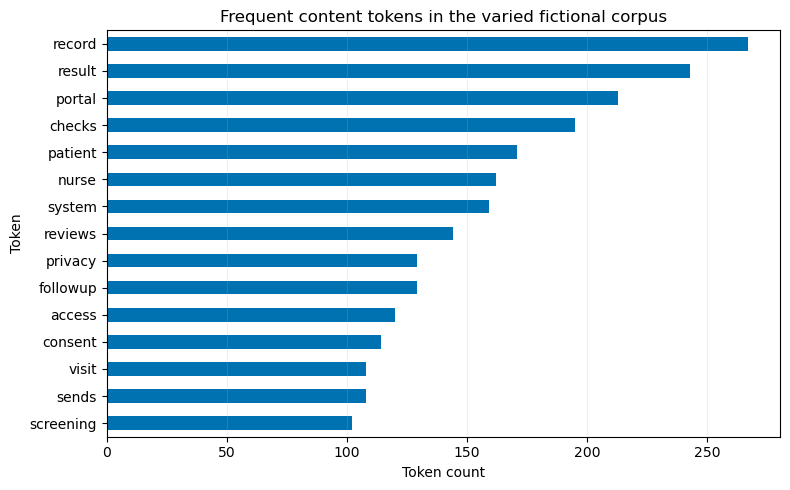

In [4]:
DISPLAY_STOPWORDS = STOPWORDS | {'and','after','before','for','from','in','is','to','using','when','whether'}
counts = Counter(token for row in tokenized_sentences for token in row if token not in DISPLAY_STOPWORDS)
frequency = pd.Series(counts).sort_values(ascending=False).head(15).sort_values()
ax = frequency.plot.barh(figsize=(8,5), color='#0072B2', title='Frequent content tokens in the varied fictional corpus')
ax.set(xlabel='Token count', ylabel='Token'); ax.grid(axis='x', alpha=.2)
plt.tight_layout(); plt.show()

### What do we see?

The varied corpus contains scheduling, results, and governance language rather than one dominant sentence pattern. Balanced-looking frequencies do not guarantee good vectors; the next cells inspect relationships directly.

## 4. Train baseline and varied skip-gram models

**Skip-gram** predicts nearby context tokens from a center token (`sg=1`); CBOW predicts the center from context. `vector_size` is the number of coordinates, `window` is context width, and `min_count` removes rare tokens. Both fits use the same main settings, making corpus design the comparison. `negative=10` and subsampling are fixed training choices.

In [5]:
WORD2VEC_CONFIG = dict(vector_size=50, window=3, min_count=1, workers=1, sg=1,
                       seed=RANDOM_STATE, epochs=100, negative=10, sample=1e-3)
baseline_model = Word2Vec(sentences=baseline_sentences, **WORD2VEC_CONFIG)
model = Word2Vec(sentences=tokenized_sentences, **WORD2VEC_CONFIG)
assert baseline_model.wv.vectors.shape == (44,50) and model.wv.vectors.shape == (83,50)
print('baseline vector matrix:', baseline_model.wv.vectors.shape)
print('varied vector matrix:  ', model.wv.vectors.shape)
print('clinic vector, first 8 coordinates:', np.round(model.wv['clinic'][:8], 3))

baseline vector matrix: (44, 50)
varied vector matrix:   (83, 50)
clinic vector, first 8 coordinates: [-0.217 -0.61   0.331 -0.193  0.301  0.985  0.158  0.871]


### What do we see?

Every retained token has one 50-coordinate embedding vector. Individual coordinates have no assigned human-readable meaning. The larger matrix reflects a broader vocabulary, not automatically a better model.

## 5. Compare similarities before making a 2-D map

Cosine similarity compares vector direction in the original 50-D space. First compare selected-word similarity distributions: a model in which almost every pair is near 1 has little contrast. Then inspect nearest neighbors. These values are corpus-dependent numerical relationships, not semantic truth.

In [6]:
SELECTED_WORDS = ['clinic','nurse','scheduler','portal','appointment','followup',
                  'laboratory','technician','result','screening','review','referral',
                  'privacy','consent','auditor','record','access','audit']
def off_diagonal_similarities(word_vectors, words):
    matrix = cosine_similarity(np.vstack([word_vectors[word] for word in words]))
    return matrix, matrix[np.triu_indices(len(words), k=1)]

baseline_similarity, baseline_pairs = off_diagonal_similarities(baseline_model.wv, SELECTED_WORDS)
similarity_matrix, varied_pairs = off_diagonal_similarities(model.wv, SELECTED_WORDS)
summary = pd.DataFrame({'baseline template': baseline_pairs, 'varied contexts': varied_pairs}).describe().loc[['min','25%','50%','75%','max']]
display(summary.round(3))

,baseline template,varied contexts
min,0.256,0.007
25%,0.377,0.188
50%,0.754,0.282
75%,0.948,0.408
max,0.998,0.839


### What do we see?

The baseline similarities are saturated: many selected words received almost interchangeable template evidence. The varied corpus produces a wider distribution. This is the key improvement—**context diversity**, not merely 1,092 rows. Absolute values are not quality scores and may vary slightly by platform.

### Neighbors and a similarity heat map

Nearest-neighbor lists are easy to cherry-pick, so we show fixed queries and a complete selected-word matrix. The heat map displays original 50-D cosine values; unlike t-SNE, it does not invent two display axes.

appointment: [('visit', 0.995), ('followup', 0.836), ('using', 0.599), ('books', 0.568)]
result     : [('reviewed', 0.56), ('records', 0.559), ('screening', 0.559), ('releases', 0.553)]
privacy    : [('access', 0.746), ('consent', 0.712), ('audit', 0.667), ('auditor', 0.647)]
audit      : [('consent', 0.804), ('access', 0.779), ('register', 0.75), ('documentation', 0.743)]


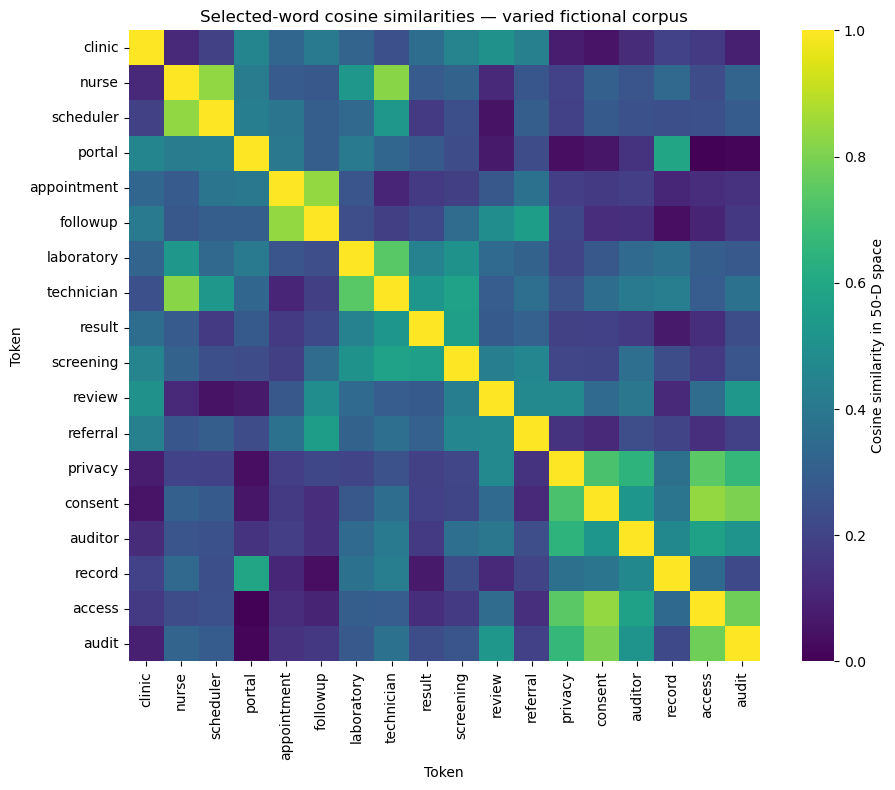

In [7]:
for word in ['appointment','result','privacy','audit']:
    print(f"{word:11}: {[(w, round(s,3)) for w,s in model.wv.most_similar(word, topn=4)]}")

fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(similarity_matrix, xticklabels=SELECTED_WORDS, yticklabels=SELECTED_WORDS,
            cmap='viridis', vmin=0, vmax=1, square=True, ax=ax,
            cbar_kws={'label':'Cosine similarity in 50-D space'})
ax.set(title='Selected-word cosine similarities — varied fictional corpus', xlabel='Token', ylabel='Token')
plt.tight_layout(); plt.show()

### What do we see?

Local relationships now differ: for example, appointment terms share contexts, result terms share contexts, and governance terms share contexts. Some cross-domain links are expected because words such as `clinic`, `portal`, `record`, and `referral` intentionally bridge sentence families. Similarity does not prove interchangeability or clinical relevance.

## 6. Map selected vectors with t-SNE

t-SNE maps the same 18 vectors from 50 dimensions to two for display. Domain labels below are analyst-supplied annotations—not training labels. Marker shape and color both distinguish them. Fixed offsets improve readability without changing point locations. Axes, orientation, cluster size, and global distances have no direct meaning.

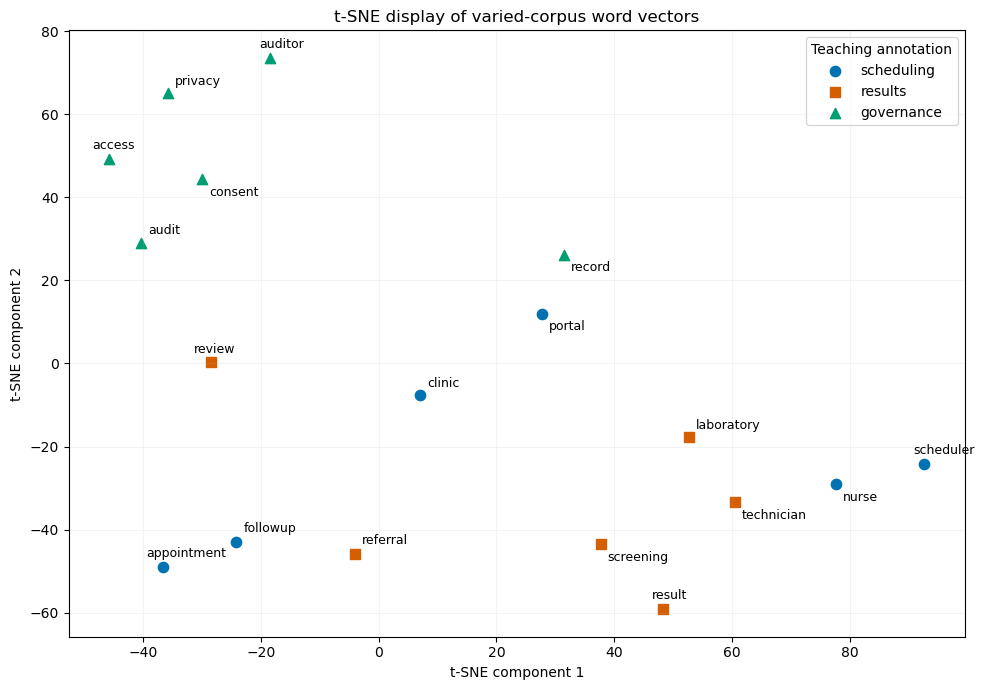

In [8]:
WORD_DOMAINS = dict.fromkeys(SELECTED_WORDS[:6], 'scheduling')
WORD_DOMAINS.update(dict.fromkeys(SELECTED_WORDS[6:12], 'results'))
WORD_DOMAINS.update(dict.fromkeys(SELECTED_WORDS[12:], 'governance'))
coords = TSNE(n_components=2, perplexity=5, init='pca', random_state=RANDOM_STATE,
              learning_rate='auto', max_iter=1000).fit_transform(np.vstack([model.wv[w] for w in SELECTED_WORDS]))
assert coords.shape == (18,2) and np.isfinite(coords).all()

styles = {'scheduling':('#0072B2','o'), 'results':('#D55E00','s'), 'governance':('#009E73','^')}
offsets = [(5,6),(5,-12),(-8,7),(5,-12),(-12,7),(5,7)]
fig, ax = plt.subplots(figsize=(10,7))
for domain, (color, marker) in styles.items():
    indices = [i for i,w in enumerate(SELECTED_WORDS) if WORD_DOMAINS[w] == domain]
    ax.scatter(coords[indices,0], coords[indices,1], c=color, marker=marker, s=55, label=domain)
    for j,i in enumerate(indices):
        ax.annotate(SELECTED_WORDS[i], coords[i], xytext=offsets[j], textcoords='offset points', fontsize=9)
ax.set(title='t-SNE display of varied-corpus word vectors', xlabel='t-SNE component 1', ylabel='t-SNE component 2')
ax.legend(title='Teaching annotation'); ax.grid(alpha=.15); plt.tight_layout(); plt.show()

### What do we see?

The display suggests local neighborhoods for this fixed run and makes bridging terms visible. Judge actual pair similarities from the heat map, not apparent long-range t-SNE distance. The supplied domain markers help reading but are not evidence that Word2Vec discovered three validated categories.

## Summary, limitations, and completion checklist

**Result:** varied contexts produced more differentiated embeddings than a Cartesian template baseline. More duplicated text would not supply new contextual evidence.

**Limits:** both corpora are small and engineered; tokenization is simplistic; neighboring tokens can reflect syntax as well as topic; vectors can encode corpus bias; t-SNE is a visualization, not validation.

- [x] Compared 240 baseline sentences with 364 unique varied sentences (1,092 training rows).
- [x] Trained deterministic 50-dimensional skip-gram models.
- [x] Inspected cosine distributions, fixed nearest-neighbor queries, a heat map, and one fixed t-SNE run.

**Try it yourself:** change only `window` and retrain, or remove the threefold repetition and compare. Keep corpus, seed, and other settings fixed. Do not run many t-SNE seeds and select the prettiest result.

Next: `Part-2_Attention_and_Self_Attention.ipynb`. See `glossary_and_quick_reference.md` and `exercises_and_answer_key.md` for review.